# Exploracion de `movies_metadata.csv`

Este notebook carga y explora el dataset ubicado en `/data/movies_metadata.csv` (o `data/movies_metadata.csv` si se ejecuta desde la raiz del proyecto).

In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)

In [16]:
# Carga robusta: fuerza columnas potencialmente conflictivas como texto.
csv_path = 'data/movies_metadata.csv'

dtype_overrides = {
    'id': 'string',
    'budget': 'string',
    'revenue': 'string',
    'popularity': 'string',
    'runtime': 'string',
    'vote_count': 'string',
    'vote_average': 'string',
}

df = pd.read_csv(csv_path, low_memory=False)
print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
df.head()

Filas: 45,466 | Columnas: 24


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,[{'name': 'Twentieth Century Fox Film Corporat...,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,"[{'name': 'Sandollar Productions', 'id': 5842}...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [17]:
df.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity',
       'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title',
       'video', 'vote_average', 'vote_count'],
      dtype='object')

In [18]:
# Limpieza basica para analisis numerico.
numeric_cols = ['budget', 'revenue', 'runtime', 'popularity', 'vote_count', 'vote_average']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

df[['budget', 'revenue', 'runtime', 'popularity', 'vote_count', 'vote_average', 'release_date', 'release_year']].head()

,budget,revenue,runtime,popularity,vote_count,vote_average,release_date,release_year
0,30000000.0,373554033.0,81.0,21.946943,5415.0,7.7,1995-10-30,1995.0
1,65000000.0,262797249.0,104.0,17.015539,2413.0,6.9,1995-12-15,1995.0
2,0.0,0.0,101.0,11.712900,92.0,6.5,1995-12-22,1995.0
3,16000000.0,81452156.0,127.0,3.859495,34.0,6.1,1995-12-22,1995.0
4,0.0,76578911.0,106.0,8.387519,173.0,5.7,1995-02-10,1995.0


In [19]:
# Calidad de datos: nulos y duplicados.
missing = (
    df.isna().sum()
      .sort_values(ascending=False)
      .rename('missing_values')
      .to_frame()
)
missing['missing_pct'] = (missing['missing_values'] / len(df) * 100).round(2)

print(f'Duplicados exactos: {df.duplicated().sum():,}')
missing.head(15)

Duplicados exactos: 17


,missing_values,missing_pct
belongs_to_collection,40972,90.12
homepage,37684,82.88
tagline,25054,55.10
overview,954,2.10
poster_path,386,0.85
runtime,263,0.58
release_year,90,0.20
release_date,90,0.20
status,87,0.19
imdb_id,17,0.04


In [20]:
# Estadisticas descriptivas de columnas numericas.
df[numeric_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).T

,count,mean,std,min,25%,50%,75%,90%,95%,max
budget,45463.0,4.224579e+06,1.742413e+07,0.0,0.000000,0.000000,0.000000,8.000000e+06,2.500000e+07,3.800000e+08
revenue,45460.0,1.120935e+07,6.433225e+07,0.0,0.000000,0.000000,0.000000,8.267610e+06,4.780892e+07,2.787965e+09
runtime,45203.0,9.412820e+01,3.840781e+01,0.0,85.000000,95.000000,107.000000,1.230000e+02,1.380000e+02,1.256000e+03
popularity,45460.0,2.921478e+00,6.005414e+00,0.0,0.385948,1.127685,3.678902,8.329721e+00,1.106157e+01,5.474883e+02
vote_count,45460.0,1.098973e+02,4.913104e+02,0.0,3.000000,10.000000,34.000000,1.600000e+02,4.340000e+02,1.407500e+04
vote_average,45460.0,5.618207e+00,1.924216e+00,0.0,5.000000,6.000000,6.800000,7.400000e+00,7.800000e+00,1.000000e+01


In [21]:
# Idiomas mas frecuentes.
df['original_language'].fillna('NA').value_counts().head(15)

original_language
en    32269
fr     2438
it     1529
ja     1350
de     1080
es      994
ru      826
hi      508
ko      444
zh      409
sv      384
pt      316
cn      313
fi      297
nl      248
Name: count, dtype: int64

In [22]:
# Top peliculas por revenue y por popularidad.
top_revenue = df[['title', 'release_year', 'revenue', 'budget', 'vote_average', 'vote_count']].nlargest(10, 'revenue')
top_popularity = df[['title', 'release_year', 'popularity', 'vote_average', 'vote_count']].nlargest(10, 'popularity')

print('Top 10 revenue')
display(top_revenue)
print('Top 10 popularidad')
display(top_popularity)

Top 10 revenue


,title,release_year,revenue,budget,vote_average,vote_count
14551,Avatar,2009.0,2.787965e+09,237000000.0,7.2,12114.0
26555,Star Wars: The Force Awakens,2015.0,2.068224e+09,245000000.0,7.5,7993.0
1639,Titanic,1997.0,1.845034e+09,200000000.0,7.5,7770.0
17818,The Avengers,2012.0,1.519558e+09,220000000.0,7.4,12000.0
25084,Jurassic World,2015.0,1.513529e+09,150000000.0,6.5,8842.0
28830,Furious 7,2015.0,1.506249e+09,190000000.0,7.3,4253.0
26558,Avengers: Age of Ultron,2015.0,1.405404e+09,280000000.0,7.3,6908.0
17437,Harry Potter and the Deathly Hallows: Part 2,2011.0,1.342000e+09,125000000.0,7.9,6141.0
22110,Frozen,2013.0,1.274219e+09,150000000.0,7.3,5440.0
42222,Beauty and the Beast,2017.0,1.262886e+09,160000000.0,6.8,5530.0


Top 10 popularidad


,title,release_year,popularity,vote_average,vote_count
30700,Minions,2015.0,547.488298,6.4,4729.0
33356,Wonder Woman,2017.0,294.337037,7.2,5025.0
42222,Beauty and the Beast,2017.0,287.253654,6.8,5530.0
43644,Baby Driver,2017.0,228.032744,7.2,2083.0
24455,Big Hero 6,2014.0,213.849907,7.8,6289.0
26564,Deadpool,2016.0,187.860492,7.4,11444.0
26566,Guardians of the Galaxy Vol. 2,2017.0,185.330992,7.6,4858.0
14551,Avatar,2009.0,185.070892,7.2,12114.0
24351,John Wick,2014.0,183.870374,7.0,5499.0
23675,Gone Girl,2014.0,154.801009,7.9,6023.0


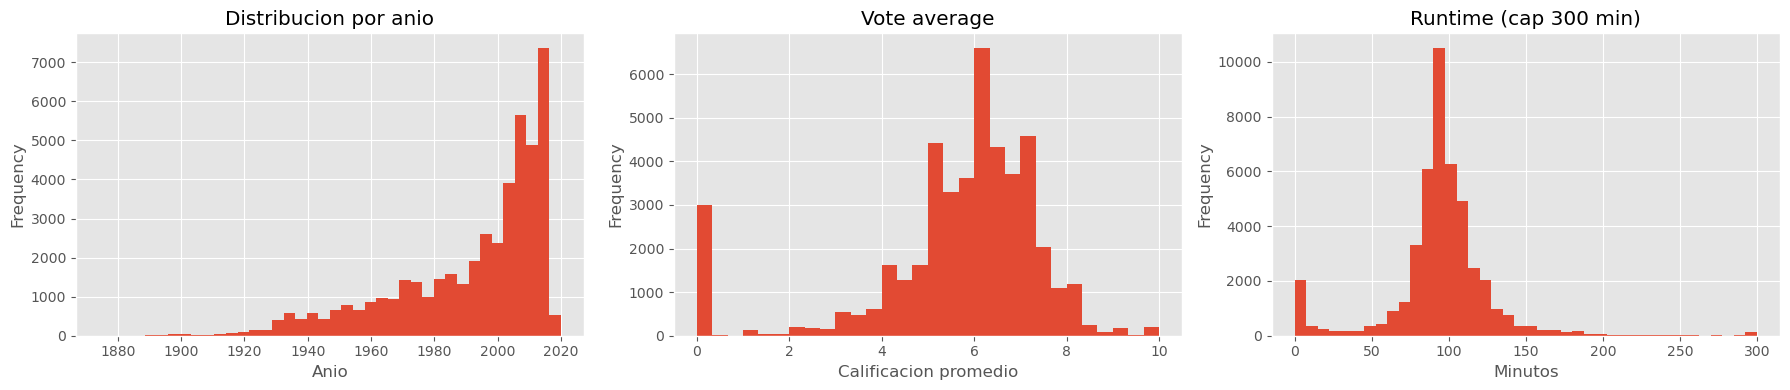

In [23]:
# Visualizaciones rapidas.
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

df['release_year'].dropna().astype(int).plot.hist(bins=40, ax=axes[0], title='Distribucion por anio')
axes[0].set_xlabel('Anio')

df['vote_average'].dropna().plot.hist(bins=30, ax=axes[1], title='Vote average')
axes[1].set_xlabel('Calificacion promedio')

df['runtime'].dropna().clip(upper=300).plot.hist(bins=40, ax=axes[2], title='Runtime (cap 300 min)')
axes[2].set_xlabel('Minutos')

plt.tight_layout()
plt.show()

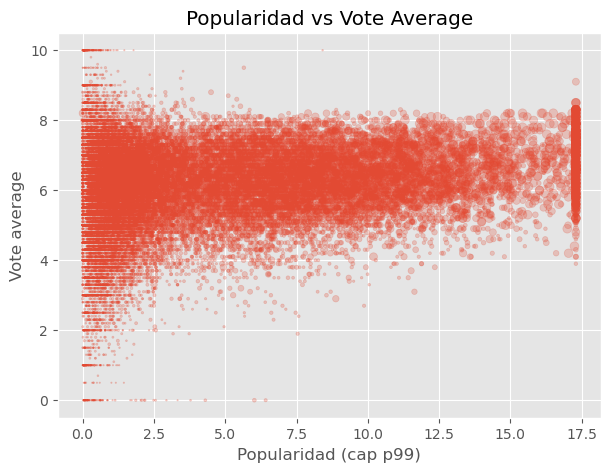

In [24]:
# Relacion entre popularidad y calificacion (solo filas validas).
subset = df[['popularity', 'vote_average', 'vote_count']].dropna()
subset = subset[subset['vote_count'] > 0]

plt.figure(figsize=(7, 5))
plt.scatter(
    subset['popularity'].clip(upper=subset['popularity'].quantile(0.99)),
    subset['vote_average'],
    s=np.sqrt(subset['vote_count']).clip(1, 40),
    alpha=0.25
)
plt.title('Popularidad vs Vote Average')
plt.xlabel('Popularidad (cap p99)')
plt.ylabel('Vote average')
plt.show()